# 08 - DRM box: build, export geometry, visualize

This notebook builds a `DRMBox`, exports its geometry to a `.h5drm` file with
`export_drm_geometry` (no FK run, so it is instant), and plots a 3D scatter of
the DRM stations colored by internal vs external boundary.

The figure is saved as a `.png` in this folder.

## Build the model and the DRM box

A `DRMBox` is a hollow shell of stations: an interior boundary plus an exterior
boundary. The QA station sits at the box center. We use the SCEC LOH.1 crust and
a single Gaussian point source (only needed to instantiate the model).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from shakermaker.shakermaker import ShakerMaker
from shakermaker.cm_library.LOH import SCEC_LOH_1
from shakermaker.pointsource import PointSource
from shakermaker.faultsource import FaultSource
from shakermaker.stf_extensions.gaussian import Gaussian
from shakermaker.sl_extensions import DRMBox

crust = SCEC_LOH_1()

sigma = 0.06
t0 = 6 * sigma
M0 = 1e18 / 5e14 / 2
stf = Gaussian(t0=t0, freq=1 / sigma, M0=M0, derivative=False)
source = PointSource([0, 0, 2], [0, 90, 0], stf=stf)
fault = FaultSource([source], metadata={"name": "src"})

dx = 0.5
drm = DRMBox([6, 8, 0], [3, 3, 2], [dx, dx, dx], metadata={"name": "drm_box"})
model = ShakerMaker(crust, fault, drm)
print("DRM stations (incl. QA):", drm.nstations)


    ▄████████     ▄█    █▄     ▄████████     ▄█   ▄█▄    ▄████████    ▄████████
    ███    ███   ███    ███    ███    ███    ███ ▄███▀   ███    ███   ███    ███
    ███    █▀    ███    ███    ███    ███    ███▐██▀     ███    █▀    ███    ███
    ███         ▄███▄▄▄▄███▄▄  ███    ███   ▄█████▀     ▄███▄▄▄      ▄███▄▄▄▄██▀
  ▀███████████  ▀███▀▀▀▀███▀  ▀███████████  ▀█████▄    ▀▀███▀▀▀     ▀▀███▀▀▀▀▀
           ███   ███    ███    ███    ███    ███▐██▄     ███    █▄   ▀███████████
     ▄█    ███   ███    ███    ███    ███    ███ ▀███▄   ███    ███   ███    ███
   ▄████████▀    ███    █▀     ███    █▀     ███   ▀█▀   ██████████   ███    ███
                                                                      ███    ███

         ▄▄▄▄███▄▄▄▄      ▄████████    ▄█   ▄█▄    ▄████████    ▄████████
       ▄██▀▀▀███▀▀▀██▄   ███    ███    ███ ▄███▀   ███    ███   ███    ███
       ███   ███   ███   ███    ███    ███▐██▀     ███    █▀    ███    ███
       ███   ███   ███   ███    ███   ▄█████▀  

## Preview the model before running
Before executing, we inspect the crust (layered column + velocity profile), the source geometry, and its source time function (STF). Each figure is saved as a PNG in this folder.

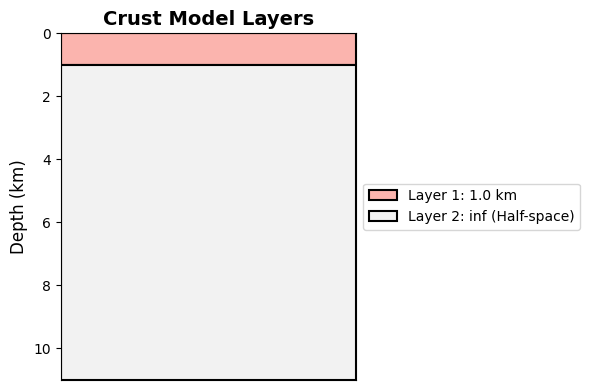

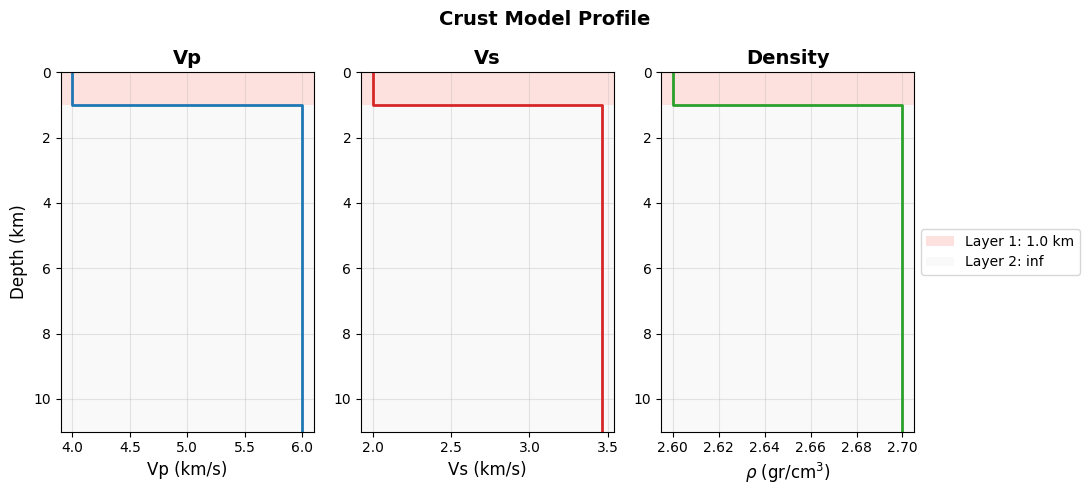

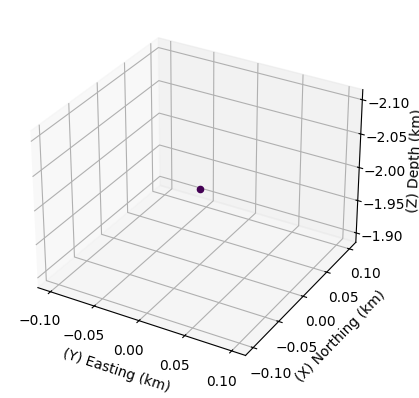

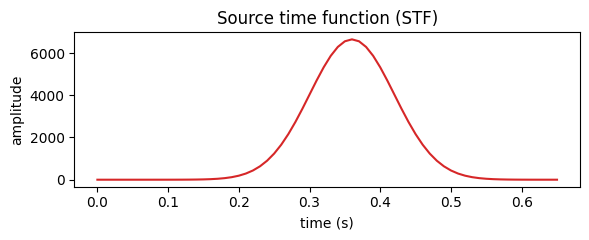

In [2]:
import matplotlib.pyplot as plt
from shakermaker.tools.plotting import SourcePlot

dt = 0.025

crust.plot()
plt.gcf().savefig("crust_layers.png", dpi=150, bbox_inches="tight")

crust.plot_profile()
plt.gcf().savefig("crust_velocity_profile.png", dpi=150, bbox_inches="tight")

for _s in fault:
    _s.stf.dt = dt
SourcePlot(fault, show=False).savefig("source_geometry.png", dpi=150, bbox_inches="tight")

_stf = fault.get_source_by_id(0).stf
fig_stf, ax_stf = plt.subplots(figsize=(6, 2.5))
ax_stf.plot(_stf.t, _stf.data, color="tab:red", lw=1.5)
ax_stf.set_xlabel("time (s)")
ax_stf.set_ylabel("amplitude")
ax_stf.set_title("Source time function (STF)")
fig_stf.tight_layout()
fig_stf.savefig("source_stf.png", dpi=150, bbox_inches="tight")

## Export geometry to .h5drm

`export_drm_geometry` writes station coordinates plus a 2-sample synthetic ramp
(for STKO inspection). It does NOT run the FK engine, so it is fast.

In [3]:
outfile = "drm_geometry.h5drm"
model.export_drm_geometry(outfile)

def walk(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"  DATASET {name}  shape={obj.shape}")
    else:
        print(f"GROUP   {name}")

with h5py.File(outfile, "r") as hf:
    hf.visititems(walk)


export_drm_geometry: drm_geometry.h5drm
  Receiver type: DRMBox
  Stations (excl. QA): 136
  Station coordinates: written
  QA station: written
  Time data (2 samples, linear ramp): written
  Metadata: written
Geometry file created: drm_geometry.h5drm
Use in STKO to visualise grid before running simulation.
GROUP   DRM_Data
  DATASET DRM_Data/acceleration  shape=(408, 2)
  DATASET DRM_Data/data_location  shape=(136,)
  DATASET DRM_Data/displacement  shape=(408, 2)
  DATASET DRM_Data/internal  shape=(136,)
  DATASET DRM_Data/velocity  shape=(408, 2)
  DATASET DRM_Data/xyz  shape=(136, 3)
GROUP   DRM_Metadata
  DATASET DRM_Metadata/drmbox_x0  shape=(3,)
  DATASET DRM_Metadata/drmbox_xmax  shape=()
  DATASET DRM_Metadata/drmbox_xmin  shape=()
  DATASET DRM_Metadata/drmbox_ymax  shape=()
  DATASET DRM_Metadata/drmbox_ymin  shape=()
  DATASET DRM_Metadata/drmbox_zmax  shape=()
  DATASET DRM_Metadata/drmbox_zmin  shape=()
  DATASET DRM_Metadata/dt  shape=()
  DATASET DRM_Metadata/h  shape=(

## Read coordinates back and plot

`/DRM_Data/xyz` holds the station coordinates and `/DRM_Data/internal` a boolean
flag (interior vs exterior boundary). We color the 3D scatter by that flag and
add the QA station from `/DRM_QA_Data/xyz`.

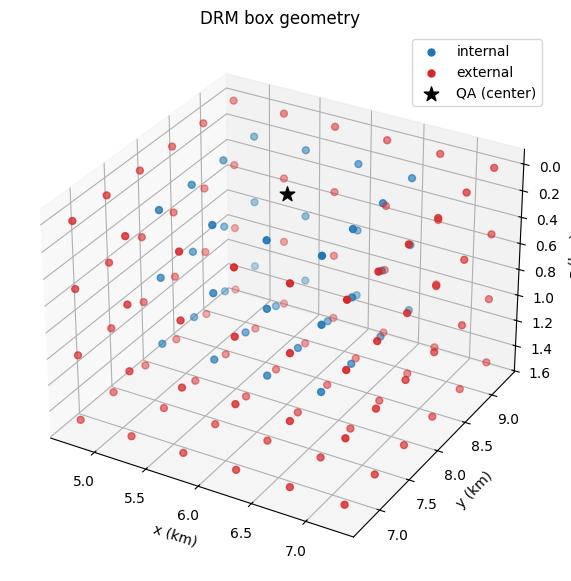

In [4]:
with h5py.File(outfile, "r") as hf:
    xyz = hf["DRM_Data/xyz"][:]
    internal = hf["DRM_Data/internal"][:]
    qa = hf["DRM_QA_Data/xyz"][:]

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(xyz[internal, 0], xyz[internal, 1], xyz[internal, 2],
           c="tab:blue", label="internal", s=25)
ax.scatter(xyz[~internal, 0], xyz[~internal, 1], xyz[~internal, 2],
           c="tab:red", label="external", s=25)
ax.scatter(qa[:, 0], qa[:, 1], qa[:, 2],
           c="k", marker="*", s=120, label="QA (center)")
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_zlabel("z (km)")
ax.invert_zaxis()
ax.legend()
ax.set_title("DRM box geometry")
plt.gcf().savefig("drm_geometry.png", dpi=150, bbox_inches="tight")
plt.show()